In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Create a Curve Fitting Regression for certain data points

## 1. Plot the data points 📌

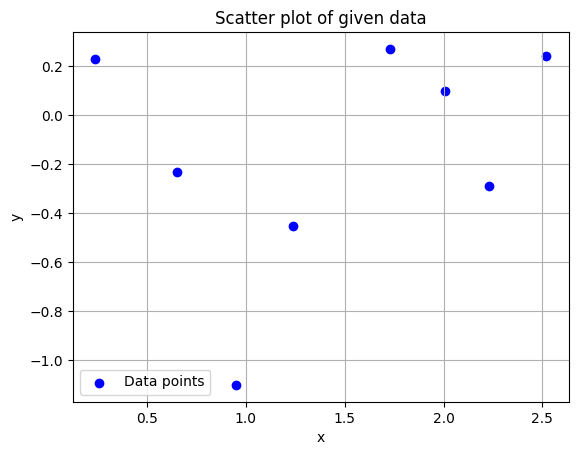

In [30]:
# Data
x = np.array([0.24, 0.65, 0.95, 1.24, 1.73, 2.01, 2.23, 2.52])
y = np.array([0.23, -0.23, -1.1, -0.45, 0.27, 0.1, -0.29, 0.24])
# x = [0, 1, 2, 3, 4, 5]
# y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1]

# Scatter plot
plt.scatter(x, y, color='blue', marker='o', label='Data points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of given data')
plt.legend()
plt.grid(True)
plt.show()


## 2. Build the tabular data with powers and products 📋
_this will be used in Normal Equations_

### a. Table for Linear, Quadratic, and Polynomial Function

In [31]:
# Compute required columns
data = {
    'x': x,
    'y': y,
    'x^2': [xi**2 for xi in x],
    'x^3': [xi**3 for xi in x],
    'x^4': [xi**4 for xi in x],
    'x^5': [xi**5 for xi in x],
    'x^6': [xi**6 for xi in x],
    'x*y': [xi*yi for xi, yi in zip(x, y)],
    'x^2*y': [xi**2 * yi for xi, yi in zip(x, y)],
    'x^3*y': [xi**3 * yi for xi, yi in zip(x, y)]
}

df_poly = pd.DataFrame(data)

# Add row of sums (Σ)
df_poly.loc['Σ'] = df_poly.sum()
df_poly

,x,y,x^2,x^3,x^4,x^5,x^6,x*y,x^2*y,x^3*y
0,0.24,0.23,0.0576,0.013824,0.003318,0.000796,0.000191,0.0552,0.013248,0.003180
1,0.65,-0.23,0.4225,0.274625,0.178506,0.116029,0.075419,-0.1495,-0.097175,-0.063164
2,0.95,-1.10,0.9025,0.857375,0.814506,0.773781,0.735092,-1.0450,-0.992750,-0.943112
3,1.24,-0.45,1.5376,1.906624,2.364214,2.931625,3.635215,-0.5580,-0.691920,-0.857981
4,1.73,0.27,2.9929,5.177717,8.957450,15.496389,26.808753,0.4671,0.808083,1.397984
5,2.01,0.10,4.0401,8.120601,16.322408,32.808040,65.944161,0.2010,0.404010,0.812060
6,2.23,-0.29,4.9729,11.089567,24.729734,55.147308,122.978496,-0.6467,-1.442141,-3.215974
7,2.52,0.24,6.3504,16.003008,40.327580,101.625502,256.096265,0.6048,1.524096,3.840722
Σ,11.57,-1.23,21.2765,43.443341,93.697717,208.899470,476.273592,-1.0711,-0.474549,0.973714


### b. Table for function
```
f(x) = a*ln(x) + b*cos(x) + c*e^x
```

In [32]:
lnx = np.log(x)
cosx = np.cos(x)
expx = np.exp(x)

data_nonlin = {
    'x': x,
    'y': y,
    'ln(x)': lnx,
    'cos(x)': cosx,
    'exp(x)': expx,
    'ln(x)^2': lnx**2,
    'ln(x)*cos(x)': lnx * cosx,
    'ln(x)*exp(x)': lnx * expx,
    'y*ln(x)': y * lnx,
    'cos(x)^2': cosx**2,
    'cos(x)*exp(x)': cosx * expx,
    'y*cos(x)': y * cosx,
    'exp(x)^2': expx**2,
    'y*exp(x)': y * expx
}

df_nonlin = pd.DataFrame(data_nonlin)

# Add row of sums (Σ)
df_nonlin.loc['Σ'] = df_nonlin.sum()
df_nonlin


,x,y,ln(x),cos(x),exp(x),ln(x)^2,ln(x)*cos(x),ln(x)*exp(x),y*ln(x),cos(x)^2,cos(x)*exp(x),y*cos(x),exp(x)^2,y*exp(x)
0,0.24,0.23,-1.427116,0.971338,1.271249,2.036661,-1.386212,-1.814220,-0.328237,0.943497,1.234813,0.223408,1.616074,0.292387
1,0.65,-0.23,-0.430783,0.796084,1.915541,0.185574,-0.342939,-0.825182,0.099080,0.633749,1.524931,-0.183099,3.669297,-0.440574
2,0.95,-1.10,-0.051293,0.581683,2.585710,0.002631,-0.029836,-0.132630,0.056423,0.338355,1.504064,-0.639851,6.685894,-2.844281
3,1.24,-0.45,0.215111,0.324796,3.455613,0.046273,0.069867,0.743342,-0.096800,0.105493,1.122370,-0.146158,11.941264,-1.555026
4,1.73,0.27,0.548121,-0.158532,5.640654,0.300437,-0.086895,3.091763,0.147993,0.025132,-0.894224,-0.042804,31.816977,1.522977
5,2.01,0.10,0.698135,-0.425219,7.463317,0.487392,-0.296860,5.210401,0.069813,0.180811,-3.173543,-0.042522,55.701106,0.746332
6,2.23,-0.29,0.802002,-0.612488,9.299866,0.643207,-0.491216,7.458507,-0.232580,0.375141,-5.696052,0.177621,86.487509,-2.696961
7,2.52,0.24,0.924259,-0.812952,12.428597,0.854255,-0.751378,11.487241,0.221822,0.660891,-10.103853,-0.195108,154.470015,2.982863
Σ,11.57,-1.23,1.278435,0.664711,44.060547,4.556429,-3.315470,25.219222,-0.062486,3.263070,-14.481495,-0.848514,352.388136,-1.992283


## 3. Normal Equation Substitute 
_Substitute sums (Σ) inside Normal Equation for finding coefficent (a, b, and c)_

In [33]:
# Extract sums from df_poly
n = len(x)
Sx = df_poly.loc['Σ', 'x']
Sy = df_poly.loc['Σ', 'y']
Sx2 = df_poly.loc['Σ', 'x^2']
Sx3 = df_poly.loc['Σ', 'x^3']
Sx4 = df_poly.loc['Σ', 'x^4']
Sx5 = df_poly.loc['Σ', 'x^5']
Sx6 = df_poly.loc['Σ', 'x^6']
Sxy = df_poly.loc['Σ', 'x*y']
Sx2y = df_poly.loc['Σ', 'x^2*y']
Sx3y = df_poly.loc['Σ', 'x^3*y']

### a. Normal equations for Linear: a + b*x

In [34]:
# Normal equations for linear: a + b*x
A_lin = np.array([
    [n,   Sx],
    [Sx,  Sx2]
], dtype=float)

b_lin = np.array([Sy, Sxy], dtype=float)

# Solve for [a, b]
solution_lin = np.linalg.solve(A_lin, b_lin)
a_lin, b_lin = solution_lin

print("Linear fit coefficients:")
print("a =", a_lin)
print("b =", b_lin)

Linear fit coefficients:
a = -0.3790527442354412
b = 0.15578409281620825


### b. Normal equations for quadratic: a + b*x + c*x^2

In [35]:
# Normal equations for quadratic: a + b*x + c*x^2
A_quad = np.array([
    [n,   Sx,  Sx2],
    [Sx,  Sx2, Sx3],
    [Sx2, Sx3, Sx4]
], dtype=float)

b_quad = np.array([Sy, Sxy, Sx2y], dtype=float)

# Solve for [a, b, c]
solution_quad = np.linalg.solve(A_quad, b_quad)
a_quad, b_quad, c_quad = solution_quad

print("Quadratic fit coefficients:")
print("a =", a_quad)
print("b =", b_quad)
print("c =", c_quad)

Quadratic fit coefficients:
a = 0.2607611555798659
b = -1.1427706273869003
c = 0.465573140047823


### c. Normal equations for cubic: a + b*x + c*x^2 + d*x^3

In [36]:
# Normal equations for cubic: a + b*x + c*x^2 + d*x^3
A_poly3 = np.array([
    [n,   Sx,  Sx2, Sx3],
    [Sx,  Sx2, Sx3, Sx4],
    [Sx2, Sx3, Sx4, Sx5],
    [Sx3, Sx4, Sx5, Sx6]
], dtype=float)

b_poly3 = np.array([Sy, Sxy, Sx2y, Sx3y], dtype=float)

# Solve for [a, b, c, d]
solution_poly3 = np.linalg.solve(A_poly3, b_poly3)
a_poly3, b_poly3, c_poly3, d_poly3 = solution_poly3

print("Cubic polynomial fit coefficients:")
print("a =", a_poly3)
print("b =", b_poly3)
print("c =", c_poly3)
print("d =", d_poly3)

Cubic polynomial fit coefficients:
a = 1.1302644724848439
b = -4.381320649158208
c = 3.314662591874953
d = -0.6929636121942309


### d. Normal Equation for
```
f(x) = a*ln(x) + b*cos(x) + c*e^x
```

In [37]:
# Extract sums from the Σ row
S_ln2      = df_nonlin.loc['Σ', 'ln(x)^2']
S_ln_cos   = df_nonlin.loc['Σ', 'ln(x)*cos(x)']
S_ln_exp   = df_nonlin.loc['Σ', 'ln(x)*exp(x)']
S_y_ln     = df_nonlin.loc['Σ', 'y*ln(x)']

S_cos2     = df_nonlin.loc['Σ', 'cos(x)^2']
S_cos_exp  = df_nonlin.loc['Σ', 'cos(x)*exp(x)']
S_y_cos    = df_nonlin.loc['Σ', 'y*cos(x)']

S_exp2     = df_nonlin.loc['Σ', 'exp(x)^2']
S_y_exp    = df_nonlin.loc['Σ', 'y*exp(x)']

# Build the coefficient matrix (3x3)
A = np.array([
    [S_ln2,    S_ln_cos,  S_ln_exp],
    [S_ln_cos, S_cos2,    S_cos_exp],
    [S_ln_exp, S_cos_exp, S_exp2]
], dtype=float)

# Build the right-hand side vector
b_vec = np.array([S_y_ln, S_y_cos, S_y_exp], dtype=float)

# Solve for [a, b, c]
solution = np.linalg.solve(A, b_vec)
a, b, c = solution

print("Fitted parameters for nonlinear model:")
print("a =", a)
print("b =", b)
print("c =", c)


Fitted parameters for nonlinear model:
a = -0.8881498861630536
b = -1.1074239354866975
c = 0.012398293316186014


## 4. Plot All Function Line
_Linear, Quadratic, Polynomial, and Non-linear function plotting_

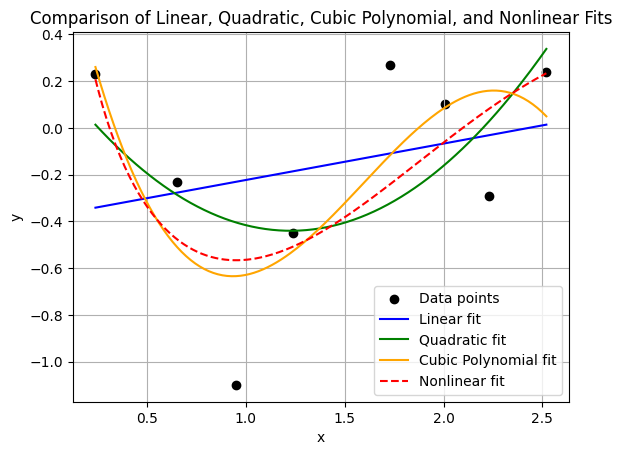

In [38]:
# Define models
def f_linear(x): 
    return a_lin + b_lin * x

def f_quad(x): 
    return a_quad + b_quad * x + c_quad * (x**2)

def f_poly3(x): 
    return a_poly3 + b_poly3 * x + c_poly3 * (x**2) + d_poly3 * (x**3)

def f_nonlin(x): 
    return a * np.log(x) + b * np.cos(x) + c * np.exp(x)
    
# Smooth x values
x_curve = np.linspace(min(x), max(x), 200)

# Linear model
y_lin = f_linear(x_curve)

# Quadratic model
y_quad = f_quad(x_curve)

# Cubic polynomial model
y_poly3 = f_poly3(x_curve)

# Nonlinear model
y_nonlin = f_nonlin(x_curve)

# Plot
plt.scatter(x, y, color='black', marker='o', label='Data points')
plt.plot(x_curve, y_lin, color='blue', label='Linear fit')
plt.plot(x_curve, y_quad, color='green', label='Quadratic fit')
plt.plot(x_curve, y_poly3, color='orange', label='Cubic Polynomial fit')
plt.plot(x_curve, y_nonlin, color='red', linestyle='--', label='Nonlinear fit')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Linear, Quadratic, Cubic Polynomial, and Nonlinear Fits')
plt.legend()
plt.grid(True)
plt.show()

## 5. Compute Φ for each model
_Linear, Quadratic, Polynomial, and Non-linear Φ(a,b,c) = Σ(f(xi)-yi)^2 calculations_

In [39]:
# Compute Phi for each model
Phi_linear = np.sum((f_linear(x) - y)**2)
Phi_quad   = np.sum((f_quad(x) - y)**2)
Phi_poly3  = np.sum((f_poly3(x) - y)**2)
Phi_nonlin = np.sum((f_nonlin(x) - y)**2)

print("Error function Φ for each model:")
print("Linear   :", Phi_linear)
print("Quadratic:", Phi_quad)
print("Cubic    :", Phi_poly3)
print("Nonlinear:", Phi_nonlin)

Error function Φ for each model:
Linear   : 1.4435254664058483
Quadratic: 1.0605518704056789
Cubic    : 0.6880107003010147
Nonlinear: 0.7724391636158525
